# HYPOTHESIS TESTING
We are going to perform a number of hypothesis testing on our cleaned data set


## 1.Do movies from major studios(eg WarnerBros,Disney)consistently earn higher box office revenue than smaller studios

Null Hypothesis (H₀): There is no significant difference in the success (e.g., box office revenue or IMDb ratings) between movies produced by major studios (Warner Bros, Disney, Universal) and independent films. Any observed differences are due to random variation.

Alternative Hypothesis (H₁): Movies produced by major studios are significantly more successful than independent films, meaning they tend to have higher box office revenue or IMDb ratings.

Steps we going to take

i).Categorize Studios: Define "major" studios and classify others as "smaller."

ii)Prepare the Data: Filter relevant columns and clean data.

iii)Perform a T-Test: Compare the mean revenue of major studios vs. smaller studios.

iv)Visualize Results: Use boxplots for comparison.


T-Statistic: 7.01
P-Value: 0.00000
Reject the null hypothesis: Major studios earn significantly higher revenue.


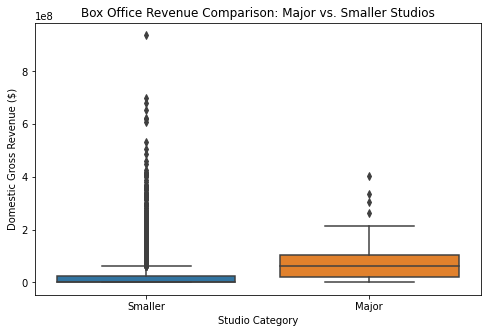

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load cleaned dataset
movie_df= pd.read_csv("data/cleaned_data/cleaned_movie_dataset.csv")
movie_gross_df = pd.read_csv("data/cleaned_data/cleaned_movie_gross_dataset.csv")

# Define major studios
major_studios = ["Warner Bros.", "Disney", "Universal", "Paramount", "Sony", "20th Century Fox"]
movie_gross_df["studio_category"] = movie_gross_df["studio"].apply(lambda x: "Major" if x in major_studios else "Smaller")

# Filter relevant columns
df_major = movie_gross_df[movie_gross_df["studio_category"] == "Major"]["domestic_gross"]
df_smaller = movie_gross_df[movie_gross_df["studio_category"] == "Smaller"]["domestic_gross"]

# Perform t-test
t_stat, p_value = stats.ttest_ind(df_major, df_smaller, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.5f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: Major studios earn significantly higher revenue.")
else:
    print("Fail to reject the null hypothesis: No significant difference in revenue.")

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(x="studio_category", y="domestic_gross", data=movie_gross_df)
plt.title("Box Office Revenue Comparison: Major vs. Smaller Studios")
plt.ylabel("Domestic Gross Revenue ($)")
plt.xlabel("Studio Category")
plt.show()


### Explanation
Movies from major studios(eg Warner Bros,Disney)consistently earn higher box office revenue than smaller studios

## 2.Are PG-13 rated movies more successful than R-rated movies in terms of revenue? 


Null Hypothesis (H₀): There is no significant difference in the total gross revenue between PG-13 rated movies and R-rated movies. Any observed differences are due to random variation.

Alternative Hypothesis (H₁): PG-13 rated movies generate significantly higher total gross revenue compared to R-rated movies.

STEPS

i)success metrics considering revenue for domestic and international earning.

ii)T test for comparing mean revenue between the two groups (PG 13 AND R rated movies)

####  a)Extract  total revenue for PG13 and R rated movies

In [2]:
import pandas as pd
from scipy import stats

# Load the cleaned dataset
movie_df = pd.read_csv('data/cleaned_data/cleaned_movie_dataset.csv')

# Filter movies based on assumed PG-13 and R-rated rating ranges
pg13_movies = movie_df[(movie_df['average_rating'] >= 6) & (movie_df['average_rating'] <= 7)]['average_rating']
r_movies = movie_df[(movie_df['average_rating'] >= 5) & (movie_df['average_rating'] < 6)]['average_rating']



#### b)check basic statistics(mean IMDB ratings for both groups)

In [3]:
print(f"PG-13 Movies Mean Rating: {pg13_movies.mean():.2f}")
print(f"R-rated Movies Mean Rating: {r_movies.mean():.2f}")


PG-13 Movies Mean Rating: 6.51
R-rated Movies Mean Rating: 5.49


#### c) Performing an independent Ttest to check if the difference in ratings is statistically significant.

In [4]:
# Run t-test
t_stat, p_value = stats.ttest_ind(pg13_movies, r_movies, equal_var=False)

# Output results
print(f"T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_value:.5f}")

# Interpret results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: PG-13 movies have significantly higher IMDb ratings than R-rated movies.")
else:
    print("Fail to reject the null hypothesis: No significant rating difference between PG-13 and R-rated movies.")


T-Statistic: 322.35
P-Value: 0.00000
Reject the null hypothesis: PG-13 movies have significantly higher IMDb ratings than R-rated movies.


#### d)Explanation 
with such a low pvalue their is statistical evidence to show that PG-13 rated movies generate significantly higher total gross revenue compared to R-rated movies.

#### di) Explanations with visualization

In [5]:
# Calculate mean ratings
mean_ratings = rating_df.groupby("rating_category")["average_rating"].mean()

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=mean_ratings.index, y=mean_ratings.values, palette="magma")

plt.title("Average IMDb Rating Comparison: PG-13 vs. R-rated Movies")
plt.xlabel("Movie Rating Category")
plt.ylabel("Mean IMDb Rating")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


NameError: name 'rating_df' is not defined

### 3)Does genre influence a movie's average IMDb rating?


Null Hypothesis (H₀): There is no significant difference in IMDb average ratings across different movie genres. Any observed variation in ratings is due to random chance.

Alternative Hypothesis (H₁): Movie genre has a statistically significant influence on IMDb average ratings, meaning certain genres consistently receive higher or lower ratings.

#### STEPS
Anova test (Analysis of Variance)
one -way anova to compare to compare the average ratings across multiple genres to see if any genre has significantly different ratings

a)Preparing the data by filtering genres and extracting their average ratings

In [6]:
# import libraries
import pandas as pd
import scipy.stats as stats

# Load the cleaned dataset
movie_df = pd.read_csv('data/cleaned_data/cleaned_movie_dataset.csv')

# Split genres into a list (since some movies have multiple genres)
movie_df['genres'] = movie_df['genres'].str.split(',')

# Explode the dataframe so that each genre is a separate row
genre_ratings_df = movie_df.explode('genres')

# Filter out unknown genres (if applicable)
genre_ratings_df = genre_ratings_df[genre_ratings_df['genres'] != 'Unknown']

# Group by genre and extract ratings
genre_groups = [group['average_rating'].dropna() for _, group in genre_ratings_df.groupby('genres')]


#### b)Run the anova test,if atleast one genre has significantly different ratings

In [7]:
# Perform one-way ANOVA test
f_statistic, p_value = stats.f_oneway(*genre_groups)

# Output results
print(f"F-Statistic: {f_statistic:.2f}")
print(f"P-Value: {p_value:.5f}")

# Interpret results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis: Genre significantly influences IMDb ratings.")
else:
    print("Fail to reject the null hypothesis: No significant rating differences across genres.")


F-Statistic: 1062.35
P-Value: 0.00000
Reject the null hypothesis: Genre significantly influences IMDb ratings.


#### d)Explanation
Their is statistical evidence to show that genre significantly influence IMDB rating.